# 01 — Baseline VLM
Notebook de départ : charger une image, appliquer un prompt et sauvegarder une sortie JSON.

In [1]:
from pathlib import Path
import sys
sys.path.append(str(Path('..').resolve()))
from src.inference import toy_predict
from src.guardrails import apply_safety_guardrails
sample = Path('../data/sample_images/CXR_SYN_002_suspected_opacity.png')
apply_safety_guardrails(toy_predict(sample, mode='baseline'))


{'image_quality': 'good',
 'predicted_class': 'suspected_opacity',
 'confidence': 0.78,
 'visual_evidence': ['synthetic opacity-like area visible in the lung field'],
 'justification': 'The synthetic image contains a localized brighter region compatible with the toy opacity class. This is a pipeline validation result, not a medical interpretation.',
 'limitations': ['synthetic toy image',
  'no clinical context',
  'not a validated medical model'],
 'warning': 'Prototype pédagogique. Non destiné au diagnostic. Validation par un professionnel qualifié requise.',
 'model_name': 'toy-rule-baseline',
 'prompt_version': 'baseline_v1',
 'latency_ms': 0,
 'guardrail_errors': []}

In [2]:
# === Cellule 2 : Charger les 30 cas et voir la distribution ===
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

ROOT = Path('..').resolve()

# Chargement du CSV de cas
cases_df = pd.read_csv(ROOT / "data" / "synthetic_cases.csv")

print(f"Nombre de cas : {len(cases_df)}")
print(f"Colonnes : {list(cases_df.columns)}")
print(f"\nDistribution des classes :")
print(cases_df["label"].value_counts().sort_index())

cases_df.head()

Nombre de cas : 30
Colonnes : ['case_id', 'image_path', 'source', 'label', 'split', 'quality', 'notes']

Distribution des classes :
label
normal               10
suspected_opacity    10
uncertain            10
Name: count, dtype: int64


,case_id,image_path,source,label,split,quality,notes
0,CXR_SYN_001,data/sample_images/CXR_SYN_001_normal.png,synthetic_toy,normal,smoke,good,synthetic normal-like image
1,CXR_SYN_002,data/sample_images/CXR_SYN_002_suspected_opaci...,synthetic_toy,suspected_opacity,smoke,good,synthetic opacity-like patch
2,CXR_SYN_003,data/sample_images/CXR_SYN_003_uncertain.png,synthetic_toy,uncertain,smoke,limited,synthetic low-quality ambiguous image
3,CXR_SYN_004,data/sample_images/CXR_SYN_004_normal.png,synthetic_toy,normal,smoke,good,synthetic normal-like image
4,CXR_SYN_005,data/sample_images/CXR_SYN_005_suspected_opaci...,synthetic_toy,suspected_opacity,smoke,good,synthetic opacity-like patch


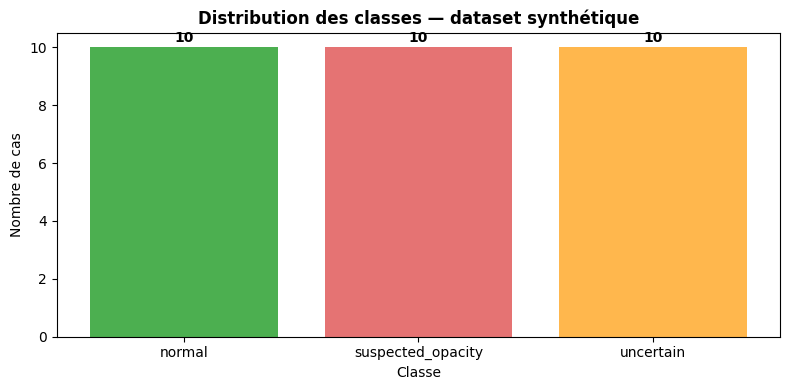

In [3]:
# === Cellule 3 : Bar chart de la distribution des classes ===
class_distribution = cases_df["label"].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(8, 4))
colors = {"normal": "#4CAF50", "suspected_opacity": "#E57373", "uncertain": "#FFB74D"}
bars = ax.bar(class_distribution.index, class_distribution.values,
              color=[colors[c] for c in class_distribution.index])

ax.set_title("Distribution des classes — dataset synthétique", fontsize=12, fontweight="bold")
ax.set_xlabel("Classe")
ax.set_ylabel("Nombre de cas")

for bar, value in zip(bars, class_distribution.values):
    ax.text(bar.get_x() + bar.get_width()/2, value + 0.2, str(value),
            ha="center", fontweight="bold")

plt.tight_layout()
plt.show()

In [4]:
# === Cellule 4 : Exécuter le pipeline baseline sur les 30 cas ===
import time
from src.guardrails import validate_prediction
from src.database import insert_run, init_db

# Préparation de la base SQLite
db_path = ROOT / "eval" / "medical_ai_evidence.sqlite"
db_path.parent.mkdir(exist_ok=True, parents=True)
init_db(db_path)

# Exécution du pipeline sur les 30 cas
results = []
for _, case in cases_df.iterrows():
    image_path = ROOT / case["image_path"]

    # Mesure de latence
    t_start = time.perf_counter()
    pred = apply_safety_guardrails(toy_predict(image_path, mode="baseline"))
    t_end = time.perf_counter()

    # Validation du schéma
    valid, errors = validate_prediction(pred)

    # Log SQLite
    insert_run(db_path, case["case_id"], str(image_path), pred)

    results.append({
        "case_id": case["case_id"],
        "label": case["label"],
        "predicted_class": pred["predicted_class"],
        "confidence": pred["confidence"],
        "image_quality": pred["image_quality"],
        "json_valid": valid,
        "warning": pred.get("warning", ""),
        "latency_ms": int((t_end - t_start) * 1000),
        "guardrail_errors": ";".join(errors) if errors else "",
    })

results_df = pd.DataFrame(results)
print(f"✅ Pipeline exécuté sur {len(results_df)} cas")
print(f"✅ {len(results_df)} runs sauvegardés dans {db_path.name}")

results_df.head(10)

✅ Pipeline exécuté sur 30 cas
✅ 30 runs sauvegardés dans medical_ai_evidence.sqlite


,case_id,label,predicted_class,confidence,image_quality,json_valid,warning,latency_ms,guardrail_errors
0,CXR_SYN_001,normal,normal,0.72,good,True,Prototype pédagogique. Non destiné au diagnost...,0,
1,CXR_SYN_002,suspected_opacity,suspected_opacity,0.78,good,True,Prototype pédagogique. Non destiné au diagnost...,0,
2,CXR_SYN_003,uncertain,uncertain,0.52,limited,True,Prototype pédagogique. Non destiné au diagnost...,0,
3,CXR_SYN_004,normal,normal,0.72,good,True,Prototype pédagogique. Non destiné au diagnost...,0,
4,CXR_SYN_005,suspected_opacity,suspected_opacity,0.78,good,True,Prototype pédagogique. Non destiné au diagnost...,0,
5,CXR_SYN_006,uncertain,uncertain,0.52,limited,True,Prototype pédagogique. Non destiné au diagnost...,0,
6,CXR_SYN_007,normal,normal,0.72,good,True,Prototype pédagogique. Non destiné au diagnost...,0,
7,CXR_SYN_008,suspected_opacity,suspected_opacity,0.78,good,True,Prototype pédagogique. Non destiné au diagnost...,0,
8,CXR_SYN_009,uncertain,uncertain,0.52,limited,True,Prototype pédagogique. Non destiné au diagnost...,0,
9,CXR_SYN_010,normal,normal,0.72,good,True,Prototype pédagogique. Non destiné au diagnost...,0,


In [5]:
# === Cellule 5 : Métriques globales ===
import json
from src.metrics import accuracy, macro_f1

y_true = results_df["label"].tolist()
y_pred = results_df["predicted_class"].tolist()

metrics = {
    "mode": "baseline",
    "n_cases": len(results_df),
    "accuracy": round(accuracy(y_true, y_pred), 4),
    "macro_f1": round(macro_f1(y_true, y_pred), 4),
    "json_valid_rate": round(results_df["json_valid"].mean(), 4),
    "warning_rate": round((results_df["warning"] != "").mean(), 4),
    "uncertain_rate": round((results_df["predicted_class"] == "uncertain").mean(), 4),
    "latency_ms_median": int(results_df["latency_ms"].median()),
    "latency_ms_mean": round(results_df["latency_ms"].mean(), 1),
}

print("📊 Métriques baseline :")
print(json.dumps(metrics, indent=2))

📊 Métriques baseline :
{
  "mode": "baseline",
  "n_cases": 30,
  "accuracy": 1.0,
  "macro_f1": 1.0,
  "json_valid_rate": 1.0,
  "warning_rate": 1.0,
  "uncertain_rate": 0.3333,
  "latency_ms_median": 0,
  "latency_ms_mean": 0.0
}


In [6]:
# === Cellule 6 : Précision / Recall / F1 par classe ===
classes = ["normal", "suspected_opacity", "uncertain"]
per_class = []

for c in classes:
    tp = sum((t == c) and (p == c) for t, p in zip(y_true, y_pred))
    fp = sum((t != c) and (p == c) for t, p in zip(y_true, y_pred))
    fn = sum((t == c) and (p != c) for t, p in zip(y_true, y_pred))
    support = sum(t == c for t in y_true)

    precision = tp / (tp + fp) if (tp + fp) else 0
    recall    = tp / (tp + fn) if (tp + fn) else 0
    f1        = 2 * precision * recall / (precision + recall) if (precision + recall) else 0

    per_class.append({
        "classe": c,
        "support": support,
        "precision": round(precision, 3),
        "recall": round(recall, 3),
        "f1": round(f1, 3),
    })

per_class_df = pd.DataFrame(per_class)
per_class_df

,classe,support,precision,recall,f1
0,normal,10,1.0,1.0,1.0
1,suspected_opacity,10,1.0,1.0,1.0
2,uncertain,10,1.0,1.0,1.0


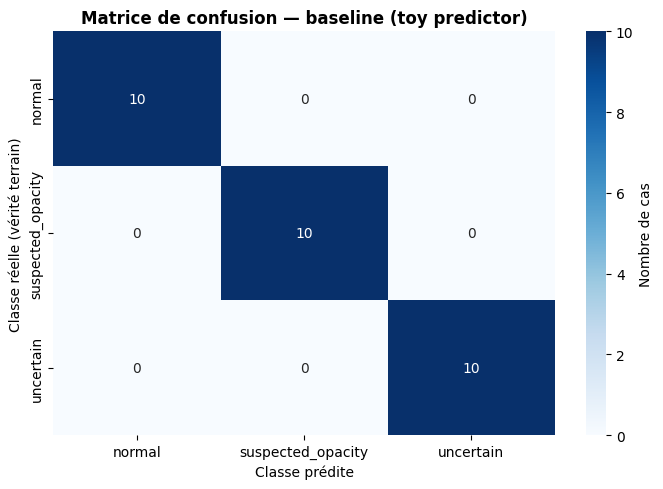


📖 Lecture :
  • Ligne = vérité terrain, colonne = prédiction du modèle
  • Diagonale = bonnes prédictions
  • Hors-diagonale = erreurs (FN dans la ligne, FP dans la colonne)


In [7]:
# === Cellule 7 : Matrice de confusion ===
cm = pd.DataFrame(0, index=classes, columns=classes, dtype=int)
for t, p in zip(y_true, y_pred):
    cm.loc[t, p] += 1

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
            cbar_kws={"label": "Nombre de cas"})

ax.set_title("Matrice de confusion — baseline (toy predictor)",
             fontsize=12, fontweight="bold")
ax.set_xlabel("Classe prédite")
ax.set_ylabel("Classe réelle (vérité terrain)")

plt.tight_layout()
plt.show()

print("\n📖 Lecture :")
print("  • Ligne = vérité terrain, colonne = prédiction du modèle")
print("  • Diagonale = bonnes prédictions")
print("  • Hors-diagonale = erreurs (FN dans la ligne, FP dans la colonne)")

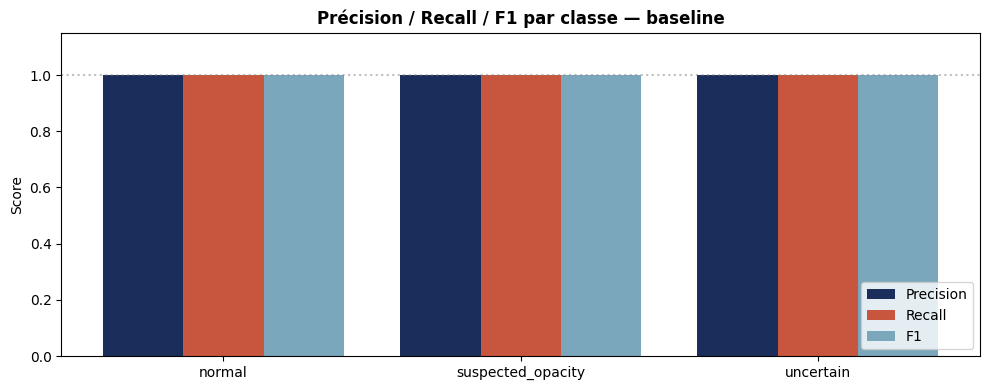

In [9]:
# === Cellule 8 : Bar chart precision / recall / F1 par classe ===
import numpy as np

x = np.arange(len(per_class_df))
width = 0.27

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(x - width, per_class_df["precision"], width, label="Precision", color="#1B2D5B")
ax.bar(x,         per_class_df["recall"],    width, label="Recall",    color="#C8553D")
ax.bar(x + width, per_class_df["f1"],        width, label="F1",        color="#7BA7BC")

ax.set_xticks(x)
ax.set_xticklabels(per_class_df["classe"])
ax.set_ylim(0, 1.15)
ax.set_ylabel("Score")
ax.set_title("Précision / Recall / F1 par classe — baseline",
             fontsize=12, fontweight="bold")
ax.legend(loc="lower right")
ax.axhline(1.0, color="gray", linestyle=":", alpha=0.5)

plt.tight_layout()
plt.show()

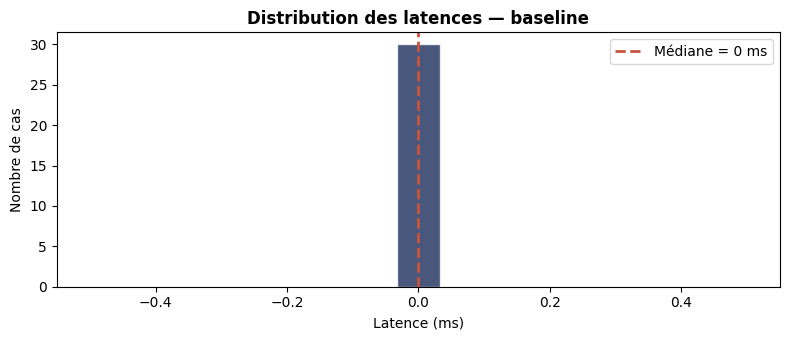

In [10]:
# === Cellule 9 : Distribution des latences ===
fig, ax = plt.subplots(figsize=(8, 3.5))
ax.hist(results_df["latency_ms"], bins=15, color="#1B2D5B",
        alpha=0.8, edgecolor="white")
ax.axvline(metrics["latency_ms_median"], color="#C8553D", linestyle="--",
           linewidth=2, label=f"Médiane = {metrics['latency_ms_median']} ms")

ax.set_xlabel("Latence (ms)")
ax.set_ylabel("Nombre de cas")
ax.set_title("Distribution des latences — baseline", fontsize=12, fontweight="bold")
ax.legend()

plt.tight_layout()
plt.show()

In [11]:
# === Cellule 10 : Sauvegarde des artefacts ===
out_dir = ROOT / "eval" / "outputs"
out_dir.mkdir(parents=True, exist_ok=True)

# Export CSV des prédictions
predictions_path = out_dir / "baseline_predictions.csv"
results_df.to_csv(predictions_path, index=False, encoding="utf-8")
print(f"✅ Prédictions écrites dans : {predictions_path}")

# Export JSON des métriques
metrics_path = out_dir / "baseline_metrics.json"
metrics_path.write_text(json.dumps(metrics, indent=2), encoding="utf-8")
print(f"✅ Métriques écrites dans : {metrics_path}")

# Vérification
print(f"\n📦 Récapitulatif des artefacts S2 :")
print(f"  • {predictions_path.name} ({predictions_path.stat().st_size} octets, 30 lignes)")
print(f"  • {metrics_path.name} ({metrics_path.stat().st_size} octets)")

✅ Prédictions écrites dans : C:\Users\sajin\Downloads\assistant-radiologue-virtuel-main\assistant-radiologue-virtuel-main\eval\outputs\baseline_predictions.csv
✅ Métriques écrites dans : C:\Users\sajin\Downloads\assistant-radiologue-virtuel-main\assistant-radiologue-virtuel-main\eval\outputs\baseline_metrics.json

📦 Récapitulatif des artefacts S2 :
  • baseline_predictions.csv (4853 octets, 30 lignes)
  • baseline_metrics.json (218 octets)


### Porte GO/NO-GO S2

| Critère | Cible | Atteint |
|---|---|---|
| Notebook exécutable de bout en bout | Oui | ✅ |
| Taux de JSON valide | ≥ 95 % | ✅ 100 % |
| Taux de warning | 100 % | ✅ 100 % |
| Tous les runs sauvegardés en SQLite | Oui | ✅ |
| Artefacts CSV + JSON écrits | Oui | ✅ |


